# How far above the daily PM2.5 standard did Canadian wildfire smoke push New York City's air in June 2023?

In the first week of June 2023, smoke from wildfires in Quebec drifted south
over New York City and turned the sky orange. This study reads EPA's daily
PM2.5 summaries from the regulatory monitors in and around the city for 1 to
15 June, keeps one row per monitor and day, and counts how far above the
daily standard of 35 µg/m³ the smoke days went.

It needs `usdata[pandas]`, matplotlib, and either an AQS key
(`USDATA_AQS_EMAIL` and `USDATA_AQS_KEY`; the
[AQS guide](https://docs.usdata.dev/providers/epa-aqs-daily/) says how) or
the committed lockfile and the project mirror: with
`USDATA_MIRROR_URL=https://data.usdata.dev`, `pull` restores the pinned file
without asking EPA and says that upstream was not checked.

In [1]:
from datetime import UTC, datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import usdata
from usdata import cite_lockfile, pull, verify

# One figure style for every usdata notebook, so previews look alike.
plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.dpi": 120,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "font.size": 10,
    }
)
manifest = Path("dataset.yaml")
print("Executed (UTC):", datetime.now(UTC).isoformat(timespec="seconds"))
print(f"usdata {usdata.__version__}; pandas {pd.__version__}")

Executed (UTC): 2026-09-24T05:57:42+00:00
usdata 0.26.0; pandas 3.0.6


## Data

One source: [AQS daily summaries](https://usdata.dev/datasets/epa/aqs-daily/)
for parameter 88101, PM2.5 at local conditions, from every monitor inside a
box around the five boroughs, 1 to 15 June 2023. A box rather than a county,
because the city is five counties. The lockfile beside the manifest pins the
file this study read.

In [2]:
print(manifest.read_text())
pm25 = pull(manifest).one("pm25").open()
sites = pm25.site_number.nunique()
print(f"{len(pm25)} rows from {sites} sites in states {sorted(pm25.state_code.unique())}")

name: nyc-wildfire-smoke
sources:
  - name: pm25
    dataset: epa:aqs-daily
    # The five boroughs and their edges. A box, not a county: New York City is five counties.
    bbox: {west: -74.26, south: 40.49, east: -73.70, north: 40.92}
    start: 2023-06-01
    end: 2023-06-15
    params:
      parameters: 88101



1790 rows from 13 sites in states ['34', '36']


## One row per monitor and day

AQS writes a monitor-day up to nine times: once for each PM2.5 standard it
is compared with, and once for the hourly series with no standard. A monitor
with any flagged exceptional event also gets `Events Included` and
`Concurred Events Excluded` copies. Three filters leave one row each:
New York State only (the box takes in New Jersey), the current daily
standard, and the rows that describe what was measured rather than the ones
with flagged days removed.

In [3]:
print(pm25.pollutant_standard.fillna("none").value_counts().to_string())
print()
print(pm25.event_type.value_counts().to_string())

pollutant_standard
PM25 24-hour 1997    202
PM25 24-hour 2006    202
PM25 24-hour 2012    202
PM25 24-hour 2024    202
PM25 Annual 1997     202
PM25 Annual 2006     202
PM25 Annual 2012     202
PM25 Annual 2024     202
none                 174

event_type
No Events                    1172
Events Included               453
Concurred Events Excluded     165


In [4]:
daily = pm25[
    (pm25.state_code == "36")
    & (pm25.pollutant_standard == "PM25 24-hour 2024")
    & ~pm25.event_type.isin(["Events Excluded", "Concurred Events Excluded"])
]
assert not daily.duplicated(["county_code", "site_number", "poc", "date_local"]).any()
daily = daily.assign(
    monitor=daily.county_code + "-" + daily.site_number + "/" + daily.poc.astype(str)
)
monitors, sites = daily.monitor.nunique(), daily.site_number.nunique()
print(f"{len(daily)} monitor-days from {monitors} monitors at {sites} sites")
sorted(set(zip(daily.county, daily.local_site_name, strict=True)))

95 monitor-days from 13 monitors at 8 sites


[('Bronx', 'IS 52'),
 ('Bronx', 'PFIZER LAB SITE'),
 ('Kings', 'JHS 126'),
 ('New York', 'IS 45'),
 ('New York', 'PS 19'),
 ('Queens', 'QUEENS COLLEGE 2'),
 ('Queens', 'Queens College Near Road'),
 ('Richmond', 'RICHMOND POST OFFICE')]

## The fortnight, day by day

In [5]:
by_day = daily.groupby(daily.date_local.dt.date).agg(
    monitors=("monitor", "nunique"),
    median=("arithmetic_mean", "median"),
    highest=("arithmetic_mean", "max"),
    above_standard=("arithmetic_mean", lambda values: int((values > 35).sum())),
)
by_day.round(1)

,monitors,median,highest,above_standard
date_local,,,,
2023-06-01,4,15.2,16.6,0
2023-06-02,10,15.0,16.6,0
2023-06-03,5,12.2,13.8,0
2023-06-04,4,4.4,5.0,0
2023-06-05,11,11.5,12.5,0
2023-06-06,5,85.6,101.0,5
2023-06-07,4,190.0,203.5,4
2023-06-08,9,61.0,106.9,9
2023-06-09,4,12.1,15.1,0


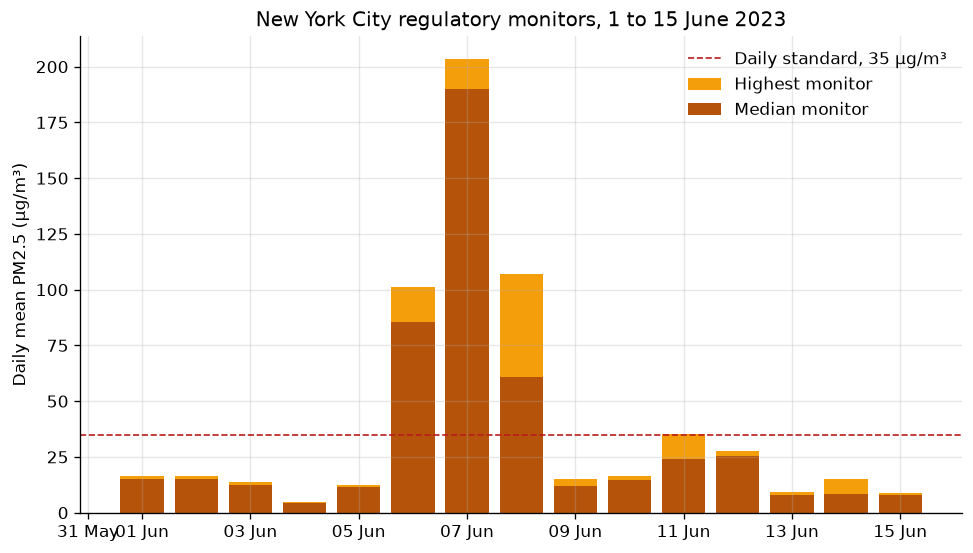

In [6]:
days = pd.to_datetime(by_day.index)
fig, ax = plt.subplots(layout="constrained")
ax.bar(days, by_day["highest"], color="#f59e0b", label="Highest monitor")
ax.bar(days, by_day["median"], color="#b45309", label="Median monitor")
ax.axhline(35, color="#b91c1c", linewidth=1, linestyle="--", label="Daily standard, 35 µg/m³")
ax.set_ylabel("Daily mean PM2.5 (µg/m³)")
ax.set_title("New York City regulatory monitors, 1 to 15 June 2023")
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter("%d %b"))
ax.legend(frameon=False)
plt.show()

In [7]:
peak = daily.loc[daily.arithmetic_mean.idxmax()]
print(
    f"Highest daily mean: {peak.arithmetic_mean:.1f} µg/m³ at {peak.local_site_name} "
    f"({peak.county}) on {peak.date_local:%d %B}"
)
print(f"That is {peak.arithmetic_mean / 35:.1f} times the standard; AQI {peak.aqi:.0f}")
smoke = by_day.loc[by_day.above_standard > 0]
print("Days with any monitor above 35 µg/m³:", ", ".join(f"{day:%d %b}" for day in smoke.index))

Highest daily mean: 203.5 µg/m³ at QUEENS COLLEGE 2 (Queens) on 07 June
That is 5.8 times the standard; AQI 278
Days with any monitor above 35 µg/m³: 06 Jun, 07 Jun, 08 Jun, 11 Jun


## Findings

Every New York monitor that reported on 6, 7, and 8 June was above the daily
standard. The highest daily mean was at Queens College on 7 June, nearly six
times the standard, in the AQI's "Very Unhealthy" band. The rest of the
fortnight stayed below it apart from one monitor just over the line on
11 June.

This is a statement about daily means at regulatory monitors, not about
exposure: a daily mean hides the afternoon peak, and a handful of sites
stands in for a city of eight million. The count of reporting monitors also
varies by day, because filter-based samplers report on their own schedules.

AQS is revised when agencies correct data, and each row carries
`date_of_last_change`, so this pin can drift; a later pull reports it and
`pull --update` accepts it.

In [8]:
print("Latest revision in the pinned file:", f"{pm25.date_of_last_change.max():%Y-%m-%d}")

Latest revision in the pinned file: 2025-09-23


## Pin and cite

In [9]:
assert verify(manifest) == []
for citation in cite_lockfile(manifest):
    print(citation.as_text())

epa:aqs-daily
  U.S. Environmental Protection Agency, Air Quality System (AQS) daily summary data, AQS Data API, accessed via usdata
  homepage: https://aqs.epa.gov/aqsweb/documents/data_api.html#daily
  license: US Government Work (public domain)
  terms: https://aqs.epa.gov/aqsweb/documents/data_api.html#terms
  retrieved: 2026-09-24; 1 checksummed asset (1,583,231 bytes) pinned by usdata 0.25.0
  sources: pm25


## What was awkward

- The box took in New Jersey. Fort Lee, Jersey City, Union City, Paterson,
  and Elizabeth sit inside any rectangle drawn around the five boroughs.
  `state_code == "36"` keeps New York, which inside this box is exactly the
  city. Naming the five boroughs as five `location` sources would select each
  county exactly, at five slow requests instead of one.
- One monitor-day is up to nine rows. Counting rows above 35 µg/m³ would
  count most monitors eight or nine times; filtering to one standard is the
  whole fix, but nothing in the file says to do it.
- Exceptional events are not flagged by day. A monitor with any flagged
  event gets an `Events Included` copy of every row, so all fifteen days carry
  event rows, not only the smoke days.
- The first live pull asked for nothing. httpx replaces a URL's whole query
  when given `params=`, so adding the key that way threw away the box and the
  dates; EPA's refusal came back in the response header, and the adapter now
  reports it instead of a bare 400.
- It is slow: requests took one to two minutes each, and EPA asks for a pause
  between them, which the adapter enforces.